# Shell UniversalXAS from the already-trained custom encoder

This notebook uses the existing all-eight FEFF custom encoder from `scratch_temp_seed42`; it does **not** retrain the encoder.

It exports shell-pooled features for every FEFF and VASP dataset:

```text
absorbing-site custom encoder state (64D)
+ inverse-distance-weighted neighbor state, 0–3 Å shell (64D)
+ inverse-distance-weighted neighbor state, 3–5 Å shell (64D)
= 192D
```

Then it trains a new all-FEFF UniversalXAS head on these shell features and fine-tunes that UniversalXAS on each FEFF/VASP dataset. Fine-tuned settings are selected by validation eta only; test eta is computed for the selected setting. Tables include paper Expert/Universal/Tuned comparisons.


In [1]:
from __future__ import annotations

import hashlib
import json
import os
import sys
from pathlib import Path

import dgl
import lightning.pytorch as pl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader

from omnixas.data.ml_data import MLData, MLSplits
from omnixas.model.xasblock import XASBlock
from omnixas.model.xasblock_regressor import XASBlockRegressor

REPO_ROOT = Path.cwd().resolve()
while not ((REPO_ROOT / "pyproject.toml").exists() and (REPO_ROOT / "omnixas").is_dir()):
    if REPO_ROOT.parent == REPO_ROOT:
        raise FileNotFoundError("Run this notebook from inside the OmniXAS repository.")
    REPO_ROOT = REPO_ROOT.parent

sys.path.insert(0, str(REPO_ROOT / "tutorial_omnixas"))
from train_all8_feff import (  # noqa: E402
    BATCH,
    ENCODER_BATCH,
    EXPORT_TASKS,
    FEFF_TASKS,
    FEATURE_SCALE,
    HEAD_WIDTHS,
    INPUT_DIM,
    OUTPUT_DIM,
    SPLITS,
    CollateGraphs,
    EncoderModel,
    FEFFDataset,
    checkpoint_score,
    compute_theta_and_phi,
    create_line_graph,
    csv_write,
    patch_matgl_gpu_constants,
    polynomial_cutoff,
    torch_load,
)
from omnixas.model.training import PlModule  # noqa: E402

RUN_NAME = "scratch_temp_seed42_shell_universal_run001"
SHELL_INNER, SHELL_OUTER = 3.0, 5.0
FEATURE_DIM = 3 * INPUT_DIM
BATCH_SIZE = 32
NUM_WORKERS = 4
GNN_DROPOUT = 0.1
MIN_LR = 1e-4
ETA_MIN = 1e-6

CUSTOM_ENCODER_RUN = Path(os.environ.get(
    "OMNIXAS_CUSTOM_ENCODER_RUN",
    REPO_ROOT.parent / "training071326" / "m3gnetAll8FEFF" / "scratch_temp_seed42",
)).expanduser().resolve()
CUSTOM_ENCODER_CKPT = CUSTOM_ENCODER_RUN / "best_all8_feff_encoder.ckpt"
if not CUSTOM_ENCODER_CKPT.is_file():
    raise FileNotFoundError(f"Missing trained custom encoder checkpoint: {CUSTOM_ENCODER_CKPT}")

RAW_ROOT = Path(os.environ.get("OMNIXAS_DATA_ROOT", REPO_ROOT.parent / "OmniXAS_data")) / "materialscloud_omnixas_raw" / "extracted"
if not RAW_ROOT.is_dir():
    raise FileNotFoundError(f"Missing raw OmniXAS data: {RAW_ROOT}")

DATA_DIR = REPO_ROOT / "tutorial_omnixas" / "ml_data"
ID_DIR = REPO_ROOT / "tutorial_omnixas" / "material_id_and_site"
OUT_ROOT = REPO_ROOT / "output" / "training" / "shellUniversalExistingCustomEncoder" / RUN_NAME
FEATURE_DIR = OUT_ROOT / "features"
HEAD_ROOT = OUT_ROOT / "heads"
OUT_ROOT.mkdir(parents=True, exist_ok=True)

UNIVERSAL = {"seed": 42, "dropout": 0.25, "lr": 7e-4, "epochs": 800, "patience": 60}
TUNED_EPOCHS = 1000
TUNED_PATIENCE = 25

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
torch.set_float32_matmul_precision("medium")
patch_matgl_gpu_constants()

split_ids = {
    task: {split: [x for x in (ID_DIR / f"{task}_{split}.txt").read_text().splitlines() if x] for split in SPLITS}
    for task in EXPORT_TASKS
}
y_true = {
    task: {split: np.atleast_2d(np.loadtxt(DATA_DIR / f"{task}_{split}_y.txt", dtype=np.float32)) for split in SPLITS}
    for task in EXPORT_TASKS
}
for task in EXPORT_TASKS:
    for split in SPLITS:
        if y_true[task][split].shape != (len(split_ids[task][split]), OUTPUT_DIM):
            raise ValueError(f"{task} {split}: ID/target row mismatch")
        if not np.isfinite(y_true[task][split]).all():
            raise ValueError(f"{task} {split}: non-finite targets")
    materials = {split: {row.rsplit("_", 1)[0] for row in split_ids[task][split]} for split in SPLITS}
    for left, right in (("train", "val"), ("train", "test"), ("val", "test")):
        overlap = materials[left] & materials[right]
        if overlap:
            raise ValueError(f"Material leakage in {task} between {left}/{right}: {sorted(overlap)[:5]}")

print("repo:", REPO_ROOT)
print("device:", DEVICE)
print("custom encoder:", CUSTOM_ENCODER_CKPT)
print("output:", OUT_ROOT)


repo: /mnt/c/Users/anton/desktop/OmniXAS
device: cuda:0
custom encoder: /mnt/c/Users/anton/desktop/training071326/m3gnetAll8FEFF/scratch_temp_seed42/best_all8_feff_encoder.ckpt
output: /mnt/c/Users/anton/desktop/OmniXAS/output/training/shellUniversalExistingCustomEncoder/scratch_temp_seed42_shell_universal_run001


In [2]:
PAPER_ETA = {
    ("Ti_FEFF", "ExpertXAS"): 6.35, ("Ti_FEFF", "UniversalXAS"): 4.19, ("Ti_FEFF", "Tuned-UniversalXAS"): 7.63,
    ("V_FEFF", "ExpertXAS"): 7.30, ("V_FEFF", "UniversalXAS"): 5.19, ("V_FEFF", "Tuned-UniversalXAS"): 9.22,
    ("Cr_FEFF", "ExpertXAS"): 8.54, ("Cr_FEFF", "UniversalXAS"): 7.13, ("Cr_FEFF", "Tuned-UniversalXAS"): 10.44,
    ("Mn_FEFF", "ExpertXAS"): 17.66, ("Mn_FEFF", "UniversalXAS"): 13.15, ("Mn_FEFF", "Tuned-UniversalXAS"): 29.81,
    ("Fe_FEFF", "ExpertXAS"): 7.51, ("Fe_FEFF", "UniversalXAS"): 6.04, ("Fe_FEFF", "Tuned-UniversalXAS"): 8.98,
    ("Co_FEFF", "ExpertXAS"): 14.47, ("Co_FEFF", "UniversalXAS"): 9.58, ("Co_FEFF", "Tuned-UniversalXAS"): 19.83,
    ("Ni_FEFF", "ExpertXAS"): 8.45, ("Ni_FEFF", "UniversalXAS"): 6.43, ("Ni_FEFF", "Tuned-UniversalXAS"): 11.21,
    ("Cu_FEFF", "ExpertXAS"): 5.19, ("Cu_FEFF", "UniversalXAS"): 2.75, ("Cu_FEFF", "Tuned-UniversalXAS"): 4.81,
    ("Ti_VASP", "ExpertXAS"): 4.75, ("Ti_VASP", "Tuned-UniversalXAS"): 5.27,
    ("Cu_VASP", "ExpertXAS"): 8.46, ("Cu_VASP", "Tuned-UniversalXAS"): 9.21,
}


def file_sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

CHECKPOINT_SHA256 = file_sha256(CUSTOM_ENCODER_CKPT)


def eta_score(prediction, target, train_target):
    prediction = np.asarray(prediction)
    if prediction.shape != target.shape or not np.isfinite(prediction).all():
        raise ValueError("Invalid predictions")
    model_mse = float(np.median(np.mean((target - prediction) ** 2, axis=1)))
    baseline = train_target.mean(axis=0, keepdims=True)
    baseline_mse = float(np.median(np.mean((target - baseline) ** 2, axis=1)))
    if model_mse <= 0:
        raise ValueError(f"Expected positive model median MSE, got {model_mse}")
    return baseline_mse / model_mse


def load_frozen_encoder():
    model = EncoderModel(dropout=GNN_DROPOUT)
    checkpoint = torch_load(CUSTOM_ENCODER_CKPT)
    state = checkpoint.get("state_dict")
    if state is None:
        raise ValueError(f"Checkpoint has no state_dict: {CUSTOM_ENCODER_CKPT}")
    encoder_state = {k.removeprefix("model.encoder."): v for k, v in state.items() if k.startswith("model.encoder.")}
    if not encoder_state:
        raise ValueError(f"Checkpoint has no model.encoder parameters: {CUSTOM_ENCODER_CKPT}")
    model.encoder.load_state_dict(encoder_state, strict=True)
    encoder = model.encoder.to(DEVICE).eval()
    for p in encoder.parameters():
        p.requires_grad = False
    return encoder


def encode_all_nodes(encoder, graph):
    graph.edata["rbf"] = encoder.bond_expansion(graph.edata["bond_dist"])
    line_graph = create_line_graph(graph.to("cpu"), encoder.threebody_cutoff).to(graph.device)
    line_graph.apply_edges(compute_theta_and_phi)
    basis = encoder.basis_expansion(line_graph)
    cutoff = polynomial_cutoff(graph.edata["bond_dist"], encoder.threebody_cutoff)
    node, edge, state = encoder.embedding(graph.ndata["node_type"], graph.edata["rbf"], None)
    for three_body, graph_layer in zip(encoder.three_body_interactions, encoder.graph_layers, strict=True):
        edge = three_body(graph, line_graph, basis, cutoff, node, edge)
        edge, node, state = graph_layer(graph, edge, node, state)
    return node


In [3]:
class ShellCollator:
    def __init__(self, encoder):
        self.graph_collator = CollateGraphs(encoder)

    def __call__(self, batch):
        graphs, sites, spectra = [], [], []
        shell_rows, shell_sources, shell_distances, shell_ids = [], [], [], []
        node_offset = 0
        for row_index, (_task, structure, site, spectrum) in enumerate(batch):
            graph = self.graph_collator.graph(structure)
            graphs.append(graph)
            sites.append(node_offset + site)
            spectra.append(spectrum)
            center = structure[site].coords
            for neighbor in structure.get_sites_in_sphere(center, SHELL_OUTER, include_index=True):
                distance = float(getattr(neighbor, "nn_distance", neighbor.distance(structure[site])))
                if distance <= 1e-6:
                    continue
                if distance <= SHELL_INNER:
                    shell_id = 0
                elif distance <= SHELL_OUTER:
                    shell_id = 1
                else:
                    continue
                shell_rows.append(row_index)
                shell_sources.append(node_offset + int(neighbor.index))
                shell_distances.append(distance)
                shell_ids.append(shell_id)
            node_offset += graph.num_nodes()
        return {
            "graph": dgl.batch(graphs),
            "site": torch.tensor(sites, dtype=torch.long),
            "y": torch.stack(spectra).float(),
            "shell_row": torch.tensor(shell_rows, dtype=torch.long),
            "shell_source": torch.tensor(shell_sources, dtype=torch.long),
            "shell_distance": torch.tensor(shell_distances, dtype=torch.float32),
            "shell_id": torch.tensor(shell_ids, dtype=torch.long),
        }


def shell_pool(node, batch):
    n_sites = len(batch["site"])
    pooled = node.new_zeros(n_sites, 2, INPUT_DIM)
    rows = batch["shell_row"].to(node.device)
    sources = batch["shell_source"].to(node.device)
    distances = batch["shell_distance"].to(node.device)
    shell_ids = batch["shell_id"].to(node.device)
    for shell_id in (0, 1):
        mask = shell_ids == shell_id
        if not mask.any():
            continue
        shell_rows = rows[mask]
        weights = 1.0 / distances[mask].clamp_min(1e-6)
        norm = node.new_zeros(n_sites).scatter_add(0, shell_rows, weights).clamp_min(1e-12)
        pooled[:, shell_id, :].index_add_(0, shell_rows, (weights / norm[shell_rows]).unsqueeze(-1) * node[sources[mask]])
    return torch.cat([node[batch["site"].to(node.device)], pooled[:, 0, :], pooled[:, 1, :]], dim=1)


In [4]:
FEATURE_CONFIG = {
    "custom_encoder_checkpoint": str(CUSTOM_ENCODER_CKPT),
    "custom_encoder_sha256": CHECKPOINT_SHA256,
    "feature_scale": FEATURE_SCALE,
    "shell_inner": SHELL_INNER,
    "shell_outer": SHELL_OUTER,
    "encoder_graph_cutoff": 4.0,
    "feature_dim": FEATURE_DIM,
}
FEATURE_DIR.mkdir(parents=True, exist_ok=True)
(FEATURE_DIR / "feature_config.json").write_text(json.dumps(FEATURE_CONFIG, indent=2) + "\n", encoding="utf-8")


def feature_complete(task, split):
    x_path = FEATURE_DIR / f"{task}_{split}_X.txt"
    y_path = FEATURE_DIR / f"{task}_{split}_y.txt"
    if not x_path.exists() or not y_path.exists():
        return False
    X = np.atleast_2d(np.loadtxt(x_path, dtype=np.float32))
    y = np.atleast_2d(np.loadtxt(y_path, dtype=np.float32))
    if X.shape != (len(split_ids[task][split]), FEATURE_DIM) or y.shape != y_true[task][split].shape:
        raise ValueError(f"Invalid cached features for {task} {split}: X={X.shape} y={y.shape}")
    if not np.isfinite(X).all() or not np.isfinite(y).all():
        raise ValueError(f"Non-finite cached features for {task} {split}")
    return True

missing = [(task, split) for task in EXPORT_TASKS for split in SPLITS if not feature_complete(task, split)]
if missing:
    encoder = load_frozen_encoder()
    collate = ShellCollator(encoder)
    with torch.no_grad():
        for task, split in missing:
            loader = DataLoader(
                FEFFDataset(REPO_ROOT, RAW_ROOT, [task], split),
                batch_size=ENCODER_BATCH,
                shuffle=False,
                collate_fn=collate,
                num_workers=NUM_WORKERS,
            )
            Xs, ys = [], []
            for batch in loader:
                node = encode_all_nodes(encoder, batch["graph"].to(DEVICE))
                features = shell_pool(node, batch)
                Xs.append((features * FEATURE_SCALE).cpu().numpy())
                ys.append(batch["y"].numpy())
            X, y = np.concatenate(Xs), np.concatenate(ys)
            if X.shape != (len(split_ids[task][split]), FEATURE_DIM) or y.shape != y_true[task][split].shape:
                raise RuntimeError(f"Invalid export for {task} {split}: X={X.shape} y={y.shape}")
            np.savetxt(FEATURE_DIR / f"{task}_{split}_X.txt", X)
            np.savetxt(FEATURE_DIR / f"{task}_{split}_y.txt", y)
            print(f"exported {task} {split}: X={X.shape} y={y.shape}")
    del encoder
    torch.cuda.empty_cache()
else:
    print("all shell feature splits cached")


exported Ti_FEFF train: X=(5140, 192) y=(5140, 141)
exported Ti_FEFF val: X=(641, 192) y=(641, 141)
exported Ti_FEFF test: X=(641, 192) y=(641, 141)
exported V_FEFF train: X=(8653, 192) y=(8653, 141)
exported V_FEFF val: X=(1080, 192) y=(1080, 141)
exported V_FEFF test: X=(1080, 192) y=(1080, 141)
exported Cr_FEFF train: X=(2457, 192) y=(2457, 141)
exported Cr_FEFF val: X=(305, 192) y=(305, 141)
exported Cr_FEFF test: X=(305, 192) y=(305, 141)
exported Mn_FEFF train: X=(13644, 192) y=(13644, 141)
exported Mn_FEFF val: X=(1704, 192) y=(1704, 141)
exported Mn_FEFF test: X=(1704, 192) y=(1704, 141)
exported Fe_FEFF train: X=(9657, 192) y=(9657, 141)
exported Fe_FEFF val: X=(1205, 192) y=(1205, 141)
exported Fe_FEFF test: X=(1205, 192) y=(1205, 141)
exported Co_FEFF train: X=(8605, 192) y=(8605, 141)
exported Co_FEFF val: X=(1074, 192) y=(1074, 141)
exported Co_FEFF test: X=(1074, 192) y=(1074, 141)
exported Ni_FEFF train: X=(3471, 192) y=(3471, 141)
exported Ni_FEFF val: X=(432, 192) y=(4

In [5]:
def load_shell_split(task):
    return MLSplits(**{
        split: MLData(
            X=np.atleast_2d(np.loadtxt(FEATURE_DIR / f"{task}_{split}_X.txt", dtype=np.float32)),
            y=np.atleast_2d(np.loadtxt(FEATURE_DIR / f"{task}_{split}_y.txt", dtype=np.float32)),
        )
        for split in SPLITS
    })


def regressor(directory, *, lr, dropout, batch, epochs, patience, scheduler="cosine", cosine_t=None, warmup_epochs=10):
    XASBlock.DROPOUT = dropout
    return XASBlockRegressor(
        directory=str(directory),
        overwrite_save_dir=False,
        input_dim=FEATURE_DIM,
        output_dim=OUTPUT_DIM,
        hidden_dims=HEAD_WIDTHS,
        batch_size=batch,
        max_epochs=epochs,
        early_stopping_patience=patience,
        initial_lr=lr,
        min_lr=MIN_LR,
        use_lr_finder=False,
        use_early_stopping=True,
        monitor_metric="val_median_mse",
        shuffle=True,
        lr_scheduler=scheduler,
        cosine_t_max=cosine_t or epochs,
        cosine_eta_min=ETA_MIN,
        warmup_epochs=warmup_epochs,
    )


def best_checkpoint(directory):
    if not directory.exists():
        return None
    ckpts = sorted(directory.glob("best*.ckpt"))
    return min(ckpts, key=checkpoint_score) if ckpts else None


def predict_ckpt(ckpt, split, hidden_dims=HEAD_WIDTHS):
    module = PlModule.load_from_checkpoint(
        checkpoint_path=str(ckpt),
        model=XASBlock(FEATURE_DIM, hidden_dims, OUTPUT_DIM),
        lr=1e-4,
    ).to(DEVICE).eval()
    preds = []
    X = split.X.astype(np.float32, copy=False)
    with torch.no_grad():
        for start in range(0, len(X), 1024):
            xb = torch.as_tensor(X[start : start + 1024], dtype=torch.float32, device=DEVICE)
            preds.append(module(xb).cpu().numpy())
    return np.concatenate(preds)


def eval_split(ckpt, split, split_name):
    data = getattr(split, split_name)
    pred = predict_ckpt(ckpt, data)
    mse = float(np.median(np.mean((data.y - pred) ** 2, axis=1)))
    base = data.y - split.train.y.mean(axis=0, keepdims=True)
    base_mse = float(np.median(np.mean(base ** 2, axis=1)))
    return {f"{split_name}_median_mse": mse, f"{split_name}_baseline_median_mse": base_mse, f"{split_name}_eta": base_mse / mse}


In [6]:
feff_splits = [load_shell_split(task) for task in FEFF_TASKS]
universal_split = MLSplits(
    train=MLData(X=np.concatenate([s.train.X for s in feff_splits]), y=np.concatenate([s.train.y for s in feff_splits])),
    val=MLData(X=np.concatenate([s.val.X for s in feff_splits]), y=np.concatenate([s.val.y for s in feff_splits])),
    test=MLData(X=np.concatenate([s.test.X for s in feff_splits]), y=np.concatenate([s.test.y for s in feff_splits])),
)

universal_dir = HEAD_ROOT / "universalXAS" / "All_FEFF" / "runs" / f"shell_universal_seed{UNIVERSAL['seed']}_lr{UNIVERSAL['lr']}_dropout{UNIVERSAL['dropout']}"
universal_ckpt = best_checkpoint(universal_dir)
if universal_ckpt is None:
    pl.seed_everything(UNIVERSAL["seed"], workers=True)
    universal = regressor(
        universal_dir,
        lr=UNIVERSAL["lr"],
        dropout=UNIVERSAL["dropout"],
        batch=BATCH_SIZE,
        epochs=UNIVERSAL["epochs"],
        patience=UNIVERSAL["patience"],
        scheduler="cosine",
        cosine_t=UNIVERSAL["epochs"],
    )
    universal.fit(universal_split)
    universal_ckpt = Path(universal.cfg.fetch_checkpoint("best"))
else:
    print("universal cached:", universal_ckpt)

universal_rows = []
for task in EXPORT_TASKS:
    split = load_shell_split(task)
    row = {"dataset": task, "model": "Shell-UniversalXAS", "checkpoint": str(universal_ckpt)}
    row.update(eval_split(universal_ckpt, split, "val"))
    row.update(eval_split(universal_ckpt, split, "test"))
    row["paper_eta"] = PAPER_ETA.get((task, "UniversalXAS"), np.nan)
    universal_rows.append(row)
universal_df = pd.DataFrame(universal_rows)
universal_df.to_csv(OUT_ROOT / "universal_eval.csv", index=False)
display(universal_df.round(3))


Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/home/anton/miniconda3/envs/omnixas/lib/python3.11/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /mnt/c/Users/anton/desktop/OmniXAS/output/training/shellUniversalExistingCustomEncoder/scratch_temp_seed42_shell_universal_run001/heads/universalXAS/All_FEFF/runs/shell_universal_seed42_lr0.0007_dropout0.25 exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name  | Type     | Params | Mode  | FLOPs
---------------------------------------------------
0 | loss  | MSELoss  | 0      | train | 0    
1 | model | XASBlock | 703 K  | train | 0    
---------------------------------------------------
703 K     Trainable

Sanity Checking: |                                                                                | 0/? [00:00…

/home/anton/miniconda3/envs/omnixas/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.
/home/anton/miniconda3/envs/omnixas/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.


Training: |                                                                                       | 0/? [00:00…

Validation: |                                                                                     | 0/? [00:00…

...

Validation: |                                                                                     | 0/? [00:00…

Validation: |                                                                                     | 0/? [00:00…

Validation: |                                                                                     | 0/? [00:00…

2026-07-22 13:51:20.164 | INFO     | omnixas.model.xasblock_regressor:fit:246 - Best models saved at /mnt/c/Users/anton/desktop/OmniXAS/output/training/shellUniversalExistingCustomEncoder/scratch_temp_seed42_shell_universal_run001/heads/universalXAS/All_FEFF/runs/shell_universal_seed42_lr0.0007_dropout0.25/best-model-epoch=219-val_median_mse=0.0024.ckpt
2026-07-22 13:51:20.167 | INFO     | omnixas.model.xasblock_regressor:fit:247 - Best validation loss: 0.005046741105616093


,dataset,model,checkpoint,val_median_mse,val_baseline_median_mse,val_eta,test_median_mse,test_baseline_median_mse,test_eta,paper_eta
0,Ti_FEFF,Shell-UniversalXAS,/mnt/c/Users/anton/desktop/OmniXAS/output/trai...,0.005,0.051,9.713,0.005,0.049,9.957,4.19
1,V_FEFF,Shell-UniversalXAS,/mnt/c/Users/anton/desktop/OmniXAS/output/trai...,0.005,0.055,11.821,0.005,0.051,10.012,5.19
2,Cr_FEFF,Shell-UniversalXAS,/mnt/c/Users/anton/desktop/OmniXAS/output/trai...,0.004,0.056,14.498,0.004,0.056,16.071,7.13
3,Mn_FEFF,Shell-UniversalXAS,/mnt/c/Users/anton/desktop/OmniXAS/output/trai...,0.002,0.047,24.624,0.002,0.046,24.827,13.15
4,Fe_FEFF,Shell-UniversalXAS,/mnt/c/Users/anton/desktop/OmniXAS/output/trai...,0.002,0.029,13.015,0.002,0.029,12.169,6.04
5,Co_FEFF,Shell-UniversalXAS,/mnt/c/Users/anton/desktop/OmniXAS/output/trai...,0.001,0.031,23.129,0.001,0.030,21.144,9.58
6,Ni_FEFF,Shell-UniversalXAS,/mnt/c/Users/anton/desktop/OmniXAS/output/trai...,0.002,0.026,14.521,0.002,0.025,15.117,6.43
7,Cu_FEFF,Shell-UniversalXAS,/mnt/c/Users/anton/desktop/OmniXAS/output/trai...,0.002,0.012,5.965,0.002,0.013,5.778,2.75
8,Ti_VASP,Shell-UniversalXAS,/mnt/c/Users/anton/desktop/OmniXAS/output/trai...,0.174,0.158,0.911,0.170,0.171,1.007,NaN
9,Cu_VASP,Shell-UniversalXAS,/mnt/c/Users/anton/desktop/OmniXAS/output/trai...,0.017,0.021,1.228,0.017,0.023,1.331,NaN


In [7]:
def tuned_sweep(task):
    if task == "Ti_VASP":
        return [
            {"name": "warmcosT600_lr5e-4_do0p1_w20", "lr": 5e-4, "dropout": 0.10, "scheduler": "warmup_cosine", "cosine_t": 600, "warmup": 20},
            {"name": "cosT600_lr5e-4_do0p25", "lr": 5e-4, "dropout": 0.25, "scheduler": "cosine", "cosine_t": 600, "warmup": 0},
            {"name": "cosT600_lr4e-4_do0p25", "lr": 4e-4, "dropout": 0.25, "scheduler": "cosine", "cosine_t": 600, "warmup": 0},
        ]
    if task == "Cu_VASP":
        return [
            {"name": "cosT600_lr5e-4_do0p25", "lr": 5e-4, "dropout": 0.25, "scheduler": "cosine", "cosine_t": 600, "warmup": 0},
            {"name": "cosT600_lr4e-4_do0p25", "lr": 4e-4, "dropout": 0.25, "scheduler": "cosine", "cosine_t": 600, "warmup": 0},
            {"name": "cosT600_lr4e-4_do0p15", "lr": 4e-4, "dropout": 0.15, "scheduler": "cosine", "cosine_t": 600, "warmup": 0},
        ]
    return [
        {"name": "cosT250_lr1e-4_do0p0", "lr": 1e-4, "dropout": 0.00, "scheduler": "cosine", "cosine_t": 250, "warmup": 0},
        {"name": "cosT250_lr1e-4_do0p1", "lr": 1e-4, "dropout": 0.10, "scheduler": "cosine", "cosine_t": 250, "warmup": 0},
        {"name": "cosT500_lr3e-4_do0p1", "lr": 3e-4, "dropout": 0.10, "scheduler": "cosine", "cosine_t": 500, "warmup": 0},
    ]

candidate_rows, selected_rows = [], []
source_dir = universal_ckpt.parent
for task in EXPORT_TASKS:
    split = load_shell_split(task)
    task_rows = []
    for cfg in tuned_sweep(task):
        out = HEAD_ROOT / "tunedUniversalXAS" / task / "runs" / cfg["name"]
        ckpt = best_checkpoint(out)
        if ckpt is None:
            tuned = regressor(
                source_dir,
                lr=cfg["lr"],
                dropout=cfg["dropout"],
                batch=BATCH[task],
                epochs=TUNED_EPOCHS,
                patience=TUNED_PATIENCE,
                scheduler=cfg["scheduler"],
                cosine_t=cfg["cosine_t"],
                warmup_epochs=cfg["warmup"],
            )
            tuned.load("best")
            tuned.cfg.directory = str(out)
            out.mkdir(parents=True, exist_ok=True)
            tuned.fit(split)
            ckpt = Path(tuned.cfg.fetch_checkpoint("best"))
        row = {"dataset": task, "setting": cfg["name"], "checkpoint": str(ckpt), "lr": cfg["lr"], "dropout": cfg["dropout"]}
        row.update(eval_split(ckpt, split, "val"))
        candidate_rows.append(row)
        task_rows.append(row)
        print(task, cfg["name"], "val_eta", round(row["val_eta"], 3))
    selected = dict(max(task_rows, key=lambda row: row["val_eta"]))
    selected.update(eval_split(Path(selected["checkpoint"]), split, "test"))
    selected["paper_expert_eta"] = PAPER_ETA.get((task, "ExpertXAS"), np.nan)
    selected["paper_universal_eta"] = PAPER_ETA.get((task, "UniversalXAS"), np.nan)
    selected["paper_tuned_eta"] = PAPER_ETA.get((task, "Tuned-UniversalXAS"), np.nan)
    selected_rows.append(selected)
    print("selected", task, "val_eta", round(selected["val_eta"], 3), "test_eta", round(selected["test_eta"], 3))

candidate_df = pd.DataFrame(candidate_rows)
selected_df = pd.DataFrame(selected_rows)
candidate_df.to_csv(OUT_ROOT / "tuned_validation_candidates.csv", index=False)
selected_df.to_csv(OUT_ROOT / "tuned_eval.csv", index=False)
display(selected_df.round(3))


2026-07-22 13:51:38.785 | INFO     | omnixas.model.xasblock_regressor:load:265 - Loading model from /mnt/c/Users/anton/desktop/OmniXAS/output/training/shellUniversalExistingCustomEncoder/scratch_temp_seed42_shell_universal_run001/heads/universalXAS/All_FEFF/runs/shell_universal_seed42_lr0.0007_dropout0.25/best-model-epoch=219-val_median_mse=0.0024.ckpt
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/home/anton/miniconda3/envs/omnixas/lib/python3.11/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /mnt/c/Users/anton/desktop/OmniXAS/output/training/shellUniversalExistingCustomEncoder/scratch_temp_seed42_shell_universal_run001/heads/tunedUniversalXAS/Ti_FEFF/runs/cosT250_lr1e-4_do0p0 exists a

Sanity Checking: |                                                                                | 0/? [00:00…

/home/anton/miniconda3/envs/omnixas/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.
/home/anton/miniconda3/envs/omnixas/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.


Training: |                                                                                       | 0/? [00:00…

Validation: |                                                                                     | 0/? [00:00…

...

Validation: |                                                                                     | 0/? [00:00…

Validation: |                                                                                     | 0/? [00:00…

2026-07-22 15:27:31.664 | INFO     | omnixas.model.xasblock_regressor:fit:246 - Best models saved at /mnt/c/Users/anton/desktop/OmniXAS/output/training/shellUniversalExistingCustomEncoder/scratch_temp_seed42_shell_universal_run001/heads/tunedUniversalXAS/Cu_VASP/runs/cosT600_lr4e-4_do0p15/best-model-epoch=239-val_median_mse=0.0027.ckpt
2026-07-22 15:27:31.665 | INFO     | omnixas.model.xasblock_regressor:fit:247 - Best validation loss: 0.00471332436427474


Cu_VASP cosT600_lr4e-4_do0p15 val_eta 7.715
selected Cu_VASP val_eta 7.715 test_eta 7.849


,dataset,setting,checkpoint,lr,dropout,val_median_mse,val_baseline_median_mse,val_eta,test_median_mse,test_baseline_median_mse,test_eta,paper_expert_eta,paper_universal_eta,paper_tuned_eta
0,Ti_FEFF,cosT500_lr3e-4_do0p1,/mnt/c/Users/anton/desktop/OmniXAS/output/trai...,0.0,0.10,0.005,0.051,11.003,0.004,0.049,10.822,6.35,4.19,7.63
1,V_FEFF,cosT500_lr3e-4_do0p1,/mnt/c/Users/anton/desktop/OmniXAS/output/trai...,0.0,0.10,0.004,0.055,12.958,0.005,0.051,11.186,7.30,5.19,9.22
2,Cr_FEFF,cosT500_lr3e-4_do0p1,/mnt/c/Users/anton/desktop/OmniXAS/output/trai...,0.0,0.10,0.003,0.056,16.457,0.004,0.056,15.506,8.54,7.13,10.44
3,Mn_FEFF,cosT500_lr3e-4_do0p1,/mnt/c/Users/anton/desktop/OmniXAS/output/trai...,0.0,0.10,0.001,0.047,35.896,0.001,0.046,32.795,17.66,13.15,29.81
4,Fe_FEFF,cosT250_lr1e-4_do0p1,/mnt/c/Users/anton/desktop/OmniXAS/output/trai...,0.0,0.10,0.002,0.029,14.557,0.002,0.029,12.999,7.51,6.04,8.98
5,Co_FEFF,cosT500_lr3e-4_do0p1,/mnt/c/Users/anton/desktop/OmniXAS/output/trai...,0.0,0.10,0.001,0.031,31.145,0.001,0.030,25.646,14.47,9.58,19.83
6,Ni_FEFF,cosT500_lr3e-4_do0p1,/mnt/c/Users/anton/desktop/OmniXAS/output/trai...,0.0,0.10,0.002,0.026,15.747,0.002,0.025,16.541,8.45,6.43,11.21
7,Cu_FEFF,cosT500_lr3e-4_do0p1,/mnt/c/Users/anton/desktop/OmniXAS/output/trai...,0.0,0.10,0.002,0.012,7.219,0.002,0.013,6.245,5.19,2.75,4.81
8,Ti_VASP,cosT600_lr4e-4_do0p25,/mnt/c/Users/anton/desktop/OmniXAS/output/trai...,0.0,0.25,0.029,0.158,5.546,0.030,0.171,5.756,4.75,NaN,5.27
9,Cu_VASP,cosT600_lr4e-4_do0p15,/mnt/c/Users/anton/desktop/OmniXAS/output/trai...,0.0,0.15,0.003,0.021,7.715,0.003,0.023,7.849,8.46,NaN,9.21


In [8]:
comparison = selected_df.copy()
comparison["paper_best_eta"] = comparison[["paper_expert_eta", "paper_tuned_eta"]].max(axis=1)
comparison["delta_vs_paper_tuned"] = comparison["test_eta"] - comparison["paper_tuned_eta"]
comparison["pct_vs_paper_tuned"] = 100 * (comparison["test_eta"] / comparison["paper_tuned_eta"] - 1)
comparison["delta_vs_paper_best"] = comparison["test_eta"] - comparison["paper_best_eta"]
comparison["pct_vs_paper_best"] = 100 * (comparison["test_eta"] / comparison["paper_best_eta"] - 1)
comparison = comparison[[
    "dataset", "setting", "val_eta", "test_eta",
    "paper_expert_eta", "paper_universal_eta", "paper_tuned_eta", "paper_best_eta",
    "delta_vs_paper_tuned", "pct_vs_paper_tuned", "delta_vs_paper_best", "pct_vs_paper_best",
]]
comparison.to_csv(OUT_ROOT / "paper_comparison.csv", index=False)
display(comparison.round(3))
print("Saved:", OUT_ROOT)


,dataset,setting,val_eta,test_eta,paper_expert_eta,paper_universal_eta,paper_tuned_eta,paper_best_eta,delta_vs_paper_tuned,pct_vs_paper_tuned,delta_vs_paper_best,pct_vs_paper_best
0,Ti_FEFF,cosT500_lr3e-4_do0p1,11.003,10.822,6.35,4.19,7.63,7.63,3.192,41.835,3.192,41.835
1,V_FEFF,cosT500_lr3e-4_do0p1,12.958,11.186,7.30,5.19,9.22,9.22,1.966,21.328,1.966,21.328
2,Cr_FEFF,cosT500_lr3e-4_do0p1,16.457,15.506,8.54,7.13,10.44,10.44,5.066,48.528,5.066,48.528
3,Mn_FEFF,cosT500_lr3e-4_do0p1,35.896,32.795,17.66,13.15,29.81,29.81,2.985,10.014,2.985,10.014
4,Fe_FEFF,cosT250_lr1e-4_do0p1,14.557,12.999,7.51,6.04,8.98,8.98,4.019,44.753,4.019,44.753
5,Co_FEFF,cosT500_lr3e-4_do0p1,31.145,25.646,14.47,9.58,19.83,19.83,5.816,29.327,5.816,29.327
6,Ni_FEFF,cosT500_lr3e-4_do0p1,15.747,16.541,8.45,6.43,11.21,11.21,5.331,47.554,5.331,47.554
7,Cu_FEFF,cosT500_lr3e-4_do0p1,7.219,6.245,5.19,2.75,4.81,5.19,1.435,29.844,1.055,20.337
8,Ti_VASP,cosT600_lr4e-4_do0p25,5.546,5.756,4.75,NaN,5.27,5.27,0.486,9.216,0.486,9.216
9,Cu_VASP,cosT600_lr4e-4_do0p15,7.715,7.849,8.46,NaN,9.21,9.21,-1.361,-14.775,-1.361,-14.775


Saved: /mnt/c/Users/anton/desktop/OmniXAS/output/training/shellUniversalExistingCustomEncoder/scratch_temp_seed42_shell_universal_run001


## Diagnostic plot

The selected tuned settings above are fixed by validation eta before this plot is used. Do not revise selection from test diagnostics.


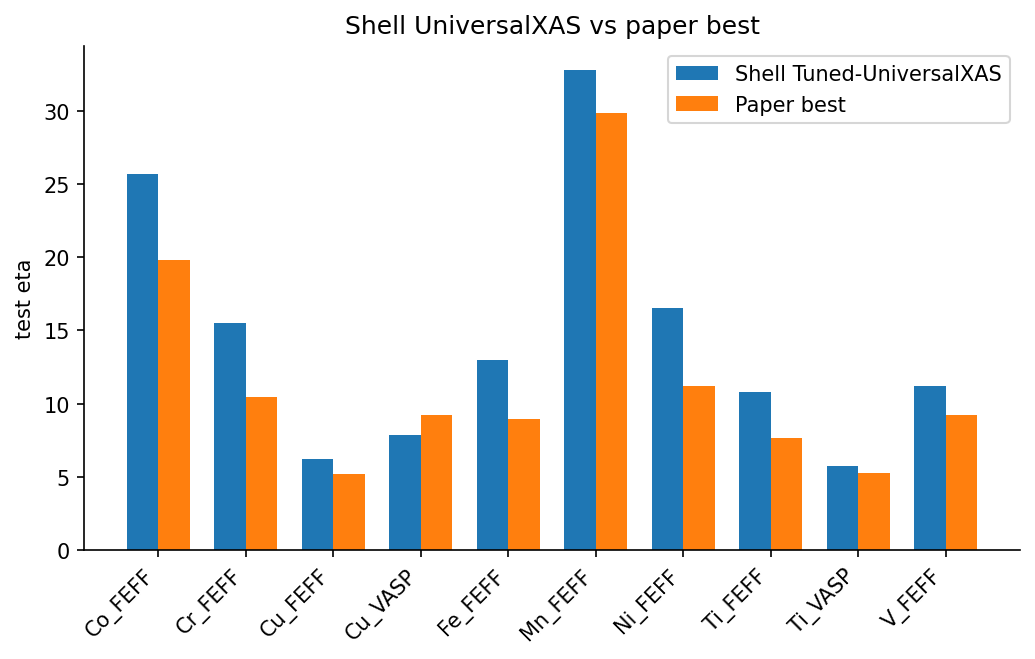

In [9]:
fig, ax = plt.subplots(figsize=(7, 4.5), dpi=150)
plot_df = comparison.sort_values("dataset")
x = np.arange(len(plot_df))
ax.bar(x - 0.18, plot_df["test_eta"], width=0.36, label="Shell Tuned-UniversalXAS")
ax.bar(x + 0.18, plot_df["paper_best_eta"], width=0.36, label="Paper best")
ax.set_xticks(x)
ax.set_xticklabels(plot_df["dataset"], rotation=45, ha="right")
ax.set_ylabel("test eta")
ax.set_title("Shell UniversalXAS vs paper best")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(OUT_ROOT / "shell_tuned_vs_paper_best.png", dpi=220)
plt.show()
